# AI Multi-Stop Planner — Hybrid (Pickup + Delivery)

**Pipeline:** Gmail → LLM Parse → Geocode → ORS Optimise → Before/After Matrix → Reply

**Graph:** Parallel matrix + optimisation nodes; before/after POV comparison; no retry overheads.

In [19]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from typing import TypedDict, Optional, List, Literal
import hashlib, logging, os, time
from datetime import datetime, timezone

load_dotenv()

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
log = logging.getLogger(__name__)

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', '')

## Data Models

In [20]:
class StopContext(BaseModel):
    store_id: str = Field(description='Store identifier, e.g. STORE-101')
    store_name: str = Field(description='Store or company name')
    pickup_address: str = Field(description='Full pickup street address')
    delivery_address: str = Field(description='Full delivery street address')
    expected_pickup_time: Optional[str] = Field(None, description="e.g. '09:00'")
    expected_delivery_time: Optional[str] = Field(None, description="e.g. '13:00'")
    temperature_control: bool = Field(False, description='True if cold-chain required')
    collection_date: Optional[str] = Field(None, description="e.g. '2024-04-12'")


class ParsedEmailOutput(BaseModel):
    sender_name: str = Field(description='Name of the person who sent the email')
    sender_company: str = Field(description='Retailer company name')
    collection_date: Optional[str] = Field(None)
    stops: List[StopContext] = Field(description='All pickup stops in the email')

## Graph State

In [21]:
class LogisticsState(TypedDict):
    # ── Core email context ─────────────────────────────────────────────
    raw_email_content:      str
    sender_email:           str
    thread_id:              str
    collection_request_id:  str
    parsed_stops:           List[dict]
    geocoded_stops:         List[dict]
    sender_company:         str
    reply_html:             str
    email_log_saved:        bool
    error:                  Optional[str]
    rejected_stops:         List[dict]

    # ── Depot ─────────────────────────────────────────────────────────
    depot_latitude:         Optional[float]
    depot_longitude:        Optional[float]

    # ── Optimisation output (VROOM /optimization) ─────────────────────
    vehicle_count:          int
    opt_summary:            Optional[dict]   # global: cost, routes, unassigned, duration, service, waiting_time
    opt_routes:             List[dict]       # per-vehicle: vehicle, cost, duration, service, waiting_time, steps[]
    ordered_stops:          List[dict]       # flat optimised stop list (stop_type, arrival, vehicle_id, ...)

    # ── Matrix comparison (before/after POV) ──────────────────────────
    unoptimized_matrix:     Optional[dict]   # legs[], total_distance_km, total_duration_min (original order)
    optimized_matrix:       Optional[dict]   # legs[], total_distance_km, total_duration_min (optimised order)

In [22]:
from tools.sheets_tools import (
    check_duplicate, save_email_log, save_parsed_stops,
    save_geocoded, save_route, save_error, save_rejection,
)
from tools.ors_tools import (
    geocode_address, optimize_route, elevation_point, distance_matrix,
)
from tools.gmail_tools import send_gmail_reply

DEPOT_ADDRESS    = os.getenv('DEPOT_ADDRESS', '')
MAX_VEHICLES     = int(os.getenv('MAX_VEHICLES', '1'))
VEHICLE_CAPACITY = int(os.getenv('VEHICLE_CAPACITY', '100'))

## Graph Nodes

In [23]:
def gmail_trigger(state: LogisticsState) -> dict:
    ts  = datetime.now(timezone.utc)
    h6  = hashlib.md5(f"{state['sender_email']}{ts.isoformat()}".encode()).hexdigest()[:6]
    req_id = f"REQ-{ts.strftime('%Y%m%d')}-{h6}"

    if check_duplicate(req_id):
        log.warning('Duplicate request: %s', req_id)
        return {'collection_request_id': req_id, 'error': 'DUPLICATE_REQUEST'}

    log.info('New request: %s (thread: %s)', req_id, state['thread_id'])
    return {'collection_request_id': req_id, 'error': None}


def route_after_trigger(state: LogisticsState) -> Literal['parser_agent', 'error_handler']:
    return 'error_handler' if state.get('error') else 'parser_agent'

In [24]:
PARSER_SYSTEM_PROMPT = """\
You are a logistics data extraction assistant.
Parse the email and extract all pickup/collection stops.

For each stop extract:
- store_id: store identifier (e.g. "STORE-101")
- store_name: name of the store or company
- pickup_address: full street pickup address
- delivery_address: full delivery street address
- expected_pickup_time: optional, e.g. "09:00"
- expected_delivery_time: optional, e.g. "13:00"
- temperature_control: true ONLY if cold-chain/refrigeration is explicitly mentioned
- collection_date: optional, e.g. "2024-04-12"

Rules:
- Use null for optional fields not mentioned.
- Do NOT invent information, only extract what is explicitly stated.
- Output must conform exactly to the schema.
"""

parser_llm = ChatOpenAI(model='gpt-4o').with_structured_output(ParsedEmailOutput)


def parser_agent(state: LogisticsState) -> dict:
    try:
        result = parser_llm.invoke([
            SystemMessage(content=PARSER_SYSTEM_PROMPT),
            HumanMessage(content=f"Parse this collection request email:\n\n{state['raw_email_content']}"),
        ])
        if not result.stops:
            raise ValueError('LLM returned zero stops')
    except Exception as e:
        log.error('Parser failed: %s', e)
        return {'error': 'PARSE_FAILED', 'parsed_stops': []}

    stops = [s.model_dump() for s in result.stops]
    log.info('Parsed %d stops (sender: %s)', len(stops), result.sender_company)
    return {'parsed_stops': stops, 'sender_company': result.sender_company, 'error': None}


def route_after_parse(state: LogisticsState) -> Literal['save_email_logs_to_sheet', 'error_handler']:
    return 'error_handler' if state.get('error') else 'save_email_logs_to_sheet'

In [25]:
def save_email_logs_to_sheet(state: LogisticsState) -> dict:
    req_id = state['collection_request_id']
    save_email_log.invoke({
        'collection_request_id': req_id,
        'sender_email':          state['sender_email'],
        'sender_company':        state.get('sender_company', ''),
        'raw_body':              state['raw_email_content'],
    })
    save_parsed_stops.invoke({'collection_request_id': req_id, 'stops': state['parsed_stops']})
    log.info('Logs saved: %d stops for %s', len(state['parsed_stops']), req_id)
    return {'email_log_saved': True}

In [26]:
def geocode_pickup_delivery_address(state: LogisticsState) -> dict:
    """
    Geocode all pickup + delivery addresses and the DEPOT.
    Depot lat/lon is stored in state so both parallel branches
    (matrix_unoptimized and route_optimization) can use it without
    re-geocoding.
    """
    stops  = state['parsed_stops']
    req_id = state['collection_request_id']
    geocoded_stops: list = []
    geocode_rows:   list = []

    # ── Geocode each stop's pickup + delivery address ─────────────────
    for i, stop in enumerate(stops):
        seq      = i + 1
        stop_geo = {**stop, 'original_sequence': seq, 'stop_index': i}

        for addr_type in ('pickup', 'delivery'):
            raw_addr = stop[f'{addr_type}_address']
            try:
                geo = geocode_address.invoke({'address': raw_addr})
                try:
                    elev = elevation_point.invoke({'latitude': geo['latitude'], 'longitude': geo['longitude']})
                    elevation = elev.get('elevation')
                except Exception as ee:
                    log.warning('Elevation failed for %s stop %d: %s', addr_type, seq, ee)
                    elevation = None

                stop_geo[f'{addr_type}_latitude']         = geo['latitude']
                stop_geo[f'{addr_type}_longitude']        = geo['longitude']
                stop_geo[f'{addr_type}_resolved_address'] = geo['address']
                stop_geo[f'{addr_type}_confidence']       = geo['confidence']
                stop_geo[f'{addr_type}_elevation_m']      = elevation

                geocode_rows.append({
                    'stop_number':      seq,
                    'store_name':       stop['store_name'],
                    'address_type':     addr_type,
                    'raw_address':      raw_addr,
                    'resolved_address': geo['address'],
                    'latitude':         geo['latitude'],
                    'longitude':        geo['longitude'],
                    'confidence':       geo['confidence'],
                    'elevation_m':      elevation,
                })
                log.info('Geocoded %s stop %d: (%.5f, %.5f)', addr_type, seq, geo['latitude'], geo['longitude'])

            except Exception as e:
                log.warning('GEOCODE_FAILED %s stop %d "%s": %s', addr_type, seq, raw_addr, e)
                stop_geo[f'{addr_type}_latitude']  = None
                stop_geo[f'{addr_type}_longitude'] = None

        geocoded_stops.append(stop_geo)

    if geocode_rows:
        save_geocoded.invoke({'collection_request_id': req_id, 'geo_data': geocode_rows})
        log.info('Geocoded sheet saved: %d entries for %s', len(geocode_rows), req_id)

    valid = [s for s in geocoded_stops if s.get('pickup_latitude') is not None]
    if not valid:
        return {'geocoded_stops': [], 'error': 'GEOCODE_FAILED'}

    # ── Geocode DEPOT once — stored in state for parallel branches ────
    depot_lat = depot_lon = None
    if DEPOT_ADDRESS:
        try:
            depot_geo = geocode_address.invoke({'address': DEPOT_ADDRESS})
            depot_lat = depot_geo['latitude']
            depot_lon = depot_geo['longitude']
            log.info('Depot geocoded: (%.5f, %.5f)', depot_lat, depot_lon)
        except Exception as e:
            log.error('Depot geocode failed: %s', e)
            return {'geocoded_stops': geocoded_stops, 'error': 'DEPOT_GEOCODE_FAILED'}
    else:
        log.error('DEPOT_ADDRESS env not set')
        return {'geocoded_stops': geocoded_stops, 'error': 'DEPOT_GEOCODE_FAILED'}

    return {
        'geocoded_stops':  geocoded_stops,
        'depot_latitude':  depot_lat,
        'depot_longitude': depot_lon,
        'error':           None,
    }


def route_after_geocode(
    state: LogisticsState,
) -> Literal['matrix_unoptimized', 'error_handler']:
    """
    Router after geocoding step.
    Returns 'matrix_unoptimized' on success (which fans out to both parallel branches).
    Returns 'error_handler' on failure.
    """
    return 'error_handler' if state.get('error') else 'matrix_unoptimized'



In [27]:
def matrix_unoptimized(state: LogisticsState) -> dict:
    """
    BEFORE-POV: call /v2/matrix with pickup stops in ORIGINAL email order.
    Runs in parallel with route_optimization.

    Location sequence: DEPOT → stop1_pickup → stop2_pickup → ... → DEPOT

    Stores result in state['unoptimized_matrix']:
      { legs[], total_distance_km, total_duration_min }
    """
    if state.get('error'):
        return {'unoptimized_matrix': None}

    depot_lat = state.get('depot_latitude')
    depot_lon = state.get('depot_longitude')
    valid = [s for s in state['geocoded_stops'] if s.get('pickup_latitude') is not None]

    if not valid or depot_lat is None:
        return {'unoptimized_matrix': None}

    locs = [{'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon}]
    for s in valid:   # original email order
        locs.append({
            'store_name': f"{s['store_name']} Pickup",
            'latitude':   s['pickup_latitude'],
            'longitude':  s['pickup_longitude'],
        })
    locs.append({'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon})

    try:
        result = distance_matrix.invoke({'locations': locs, 'profile': 'driving-car'})
        log.info('Unoptimized matrix: %.1f km | %.1f min',
                 result['total_distance_km'], result['total_duration_min'])
        return {'unoptimized_matrix': result}
    except Exception as e:
        log.warning('Unoptimized matrix failed: %s', e)
        return {'unoptimized_matrix': None}

In [28]:
def route_optimization(state: LogisticsState) -> dict:
    """
    Call ORS /optimization (VROOM) directly — no retry wrapper.
    Parses the VROOM response into state fields:
      opt_summary  — global summary (cost, routes, unassigned, duration, service, waiting_time)
      opt_routes   — per-vehicle routes with full step lists
      ordered_stops — flat list of stops in optimised sequence
      rejected_stops — stops VROOM could not assign, with reason
    Runs in parallel with matrix_unoptimized.
    """
    if state.get('error'):
        return {
            'opt_summary':   None,
            'opt_routes':    [],
            'ordered_stops': [],
            'rejected_stops': [],
            'vehicle_count': 0,
        }

    req_id    = state['collection_request_id']
    depot_lat = state['depot_latitude']
    depot_lon = state['depot_longitude']
    valid     = [s for s in state['geocoded_stops'] if s.get('pickup_latitude') is not None]

    # ── Single-stop shortcut (no VROOM call needed) ───────────────────
    if len(valid) == 1:
        s = valid[0]
        ordered_stops = [{
            'job_id':                   s['stop_index'] * 10 + 1,
            'store_id':                 s.get('store_id', ''),
            'store_name':               s['store_name'],
            'pickup_address':           s['pickup_address'],
            'delivery_address':         s.get('delivery_address', ''),
            'address':                  s['pickup_address'],
            'latitude':                 s['pickup_latitude'],
            'longitude':                s['pickup_longitude'],
            'stop_type':                'pickup',
            'vehicle_id':               1,
            'arrival_time_seconds':     28800,
            'service_duration_seconds': 300,
            'waiting_time_seconds':     0,
            'temperature_control':      s.get('temperature_control', False),
            'original_sequence':        1,
            'optimized_sequence':       1,
        }]
        summary = {'cost': 0, 'routes': 1, 'unassigned': 0, 'duration': 0, 'service': 300, 'waiting_time': 0}
        return {
            'opt_summary':   summary,
            'opt_routes':    [],
            'ordered_stops': ordered_stops,
            'rejected_stops': [],
            'vehicle_count': 1,
            'error':         None,
        }

    # ── Call VROOM /optimization ──────────────────────────────────────
    try:
        result = optimize_route.invoke({
            'stops':            valid,
            'depot_lon':        depot_lon,
            'depot_lat':        depot_lat,
            'max_vehicles':     MAX_VEHICLES,
            'vehicle_capacity': VEHICLE_CAPACITY,
            'use_pd_pairs':     True,
        })
    except Exception as e:
        log.error('ORS optimisation failed: %s', e)
        return {
            'opt_summary': None, 'opt_routes': [], 'ordered_stops': [],
            'rejected_stops': [], 'vehicle_count': 0, 'error': 'OPTIMIZATION_FAILED',
        }

    # ── Parse rejected stops from VROOM unassigned[] ──────────────────
    # VROOM unassigned entry: { "id": int, "type": "pickup|delivery|job", "location": [lon,lat] }
    job_lookup: dict = {}
    for s in valid:
        idx = s['stop_index']
        job_lookup[idx * 10 + 1] = (s, 'pickup')
        job_lookup[idx * 10 + 2] = (s, 'delivery')

    rejected_stops: list = []
    seen_indices:   set  = set()

    for job in result.get('unassigned', []):
        job_id = int(job.get('id', 0))
        entry  = job_lookup.get(job_id)
        if not entry:
            log.warning('Unassigned job %s not in stop lookup', job_id)
            continue
        stop, stop_type = entry
        idx = stop['stop_index']
        if idx in seen_indices:
            continue   # deduplicate pickup+delivery of same stop
        seen_indices.add(idx)
        reason = (
            'TIME_WINDOW_VIOLATION: Cannot be served within requested time slot'
            if stop.get('expected_pickup_time') or stop.get('expected_delivery_time')
            else 'CAPACITY_EXCEEDED: Fleet capacity insufficient for this stop'
        )
        rejected_stops.append({
            'stop_index': idx,
            'store_name': stop['store_name'],
            'store_id':   stop.get('store_id', ''),
            'reason':     reason,
            'stop_type':  stop_type,
            'address':    stop.get('pickup_address', ''),
        })

    summary       = result['summary']        # { cost, routes, unassigned, duration, service, waiting_time, ... }
    routes        = result['routes']         # per-vehicle route dicts with steps[]
    ordered_stops = result['ordered_stops']  # flat optimised stop list
    vehicle_count = len(routes)

    save_route.invoke({'collection_request_id': req_id, 'route': {
        'summary':       summary,
        'vehicle_count': vehicle_count,
        'ordered_stops': ordered_stops,
    }})
    log.info('Route optimised: %d stops, %d vehicle(s)', len(ordered_stops), vehicle_count)

    return {
        'opt_summary':   summary,
        'opt_routes':    routes,
        'ordered_stops': ordered_stops,
        'rejected_stops': rejected_stops,
        'vehicle_count': vehicle_count,
        'error':         None,
    }

In [29]:
def matrix_optimized(state: LogisticsState) -> dict:
    """
    AFTER-POV: call /v2/matrix with stops in VROOM's optimised order.
    Runs after route_optimization completes.

    Location sequence: DEPOT → optimised_stop1 → optimised_stop2 → ... → DEPOT

    Stores result in state['optimized_matrix']:
      { legs[], total_distance_km, total_duration_min }
    """
    if state.get('error') or not state.get('ordered_stops'):
        return {'optimized_matrix': None}

    depot_lat     = state.get('depot_latitude')
    depot_lon     = state.get('depot_longitude')
    ordered_stops = state['ordered_stops']

    if not ordered_stops or depot_lat is None:
        return {'optimized_matrix': None}

    locs = [{'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon}]
    for s in ordered_stops:
        locs.append({
            'store_name': f"{s['store_name']} ({s.get('stop_type', 'stop').title()})",
            'latitude':   s['latitude'],
            'longitude':  s['longitude'],
        })
    locs.append({'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon})

    try:
        result = distance_matrix.invoke({'locations': locs, 'profile': 'driving-car'})
        log.info('Optimised matrix: %.1f km | %.1f min',
                 result['total_distance_km'], result['total_duration_min'])
        return {'optimized_matrix': result}
    except Exception as e:
        log.warning('Optimised matrix failed: %s', e)
        return {'optimized_matrix': None}

In [30]:
def determine_reply(state: LogisticsState) -> dict:
    """Fan-in barrier — waits for both matrix nodes to complete, then routes."""
    return {}


def route_after_determine(
    state: LogisticsState,
) -> Literal['ai_agent_reply', 'rejection_agent_reply', 'error_handler']:
    if state.get('error'):
        return 'error_handler'
    if state.get('rejected_stops') or not state.get('ordered_stops'):
        return 'rejection_agent_reply'
    return 'ai_agent_reply'

In [31]:
def _fmt_seconds(secs: int) -> str:
    """Convert seconds to 'Xhr Ymin' string."""
    h, rem = divmod(int(secs), 3600)
    m = rem // 60
    return f'{h}h {m:02d}min' if h else f'{m}min'


def _fmt_arrival(secs: int) -> str:
    """Convert seconds-since-midnight to HH:MM."""
    h, rem = divmod(int(secs), 3600)
    return f'{h:02d}:{rem // 60:02d}'


def _build_stop_table(ordered_stops: list) -> str:
    """Render the ordered stop table (pickup + delivery rows)."""
    rows = ''
    for s in ordered_stops:
        badge = (
            '<span style="color:#e67e22">&#128310; Pickup</span>'
            if s.get('stop_type') == 'pickup'
            else '<span style="color:#2980b9">&#128311; Delivery</span>'
        )
        cold    = '&#10052;' if s.get('temperature_control') else ''
        addr    = s.get('address', s.get('pickup_address', ''))
        eta     = _fmt_arrival(s.get('arrival_time_seconds', 0))
        svc     = _fmt_seconds(s.get('service_duration_seconds', 300))
        wait    = _fmt_seconds(s.get('waiting_time_seconds', 0))
        rows += (
            f'<tr>'
            f'<td>{s.get("optimized_sequence", "")}</td>'
            f'<td>{s["store_name"]} {cold}</td>'
            f'<td>{badge}</td>'
            f'<td>{addr}</td>'
            f'<td>{eta}</td>'
            f'<td>{wait}</td>'
            f'<td>{svc}</td>'
            f'<td>V{s.get("vehicle_id", 1)}</td>'
            f'</tr>\n'
        )
    return (
        '<table border="1" cellpadding="6" cellspacing="0" '
        'style="border-collapse:collapse;font-family:Arial,sans-serif;font-size:13px">'
        '<thead><tr style="background:#2c3e50;color:white">'
        '<th>#</th><th>Store</th><th>Type</th><th>Address</th>'
        '<th>ETA</th><th>Wait</th><th>Service</th><th>Vehicle</th>'
        '</tr></thead><tbody>' + rows + '</tbody></table>'
    )


def _build_vehicle_table(opt_routes: list) -> str:
    """Per-vehicle breakdown table from VROOM routes[]."""
    rows = ''
    for r in opt_routes:
        stops = sum(
            1 for step in r.get('steps', [])
            if step.get('type') in ('job', 'pickup', 'delivery')
        )
        rows += (
            f'<tr>'
            f'<td>Vehicle {r["vehicle"]}</td>'
            f'<td>{stops}</td>'
            f'<td>{_fmt_seconds(r.get("duration", 0))}</td>'
            f'<td>{_fmt_seconds(r.get("service", 0))}</td>'
            f'<td>{_fmt_seconds(r.get("waiting_time", 0))}</td>'
            f'<td>{r.get("cost", 0)}</td>'
            f'</tr>\n'
        )
    return (
        '<table border="1" cellpadding="6" cellspacing="0" '
        'style="border-collapse:collapse;font-family:Arial,sans-serif;font-size:13px">'
        '<thead><tr style="background:#34495e;color:white">'
        '<th>Vehicle</th><th>Stops</th><th>Drive Time</th>'
        '<th>Service Time</th><th>Waiting Time</th><th>Cost (s)</th>'
        '</tr></thead><tbody>' + rows + '</tbody></table>'
    )


def _build_pov_comparison(unopt: Optional[dict], opt: Optional[dict]) -> str:
    """Before/after POV comparison block for the email."""
    if not unopt or not opt:
        return ''
    saved_km  = round(unopt['total_distance_km']  - opt['total_distance_km'],  2)
    saved_min = round(unopt['total_duration_min'] - opt['total_duration_min'], 2)
    return (
        '<table border="1" cellpadding="6" cellspacing="0" '
        'style="border-collapse:collapse;font-family:Arial,sans-serif;font-size:13px">'
        '<thead><tr style="background:#16a085;color:white">'
        '<th>Metric</th><th>Unoptimised (email order)</th>'
        '<th>Optimised (VROOM)</th><th>Saving</th>'
        '</tr></thead><tbody>'
        f'<tr><td>Distance</td>'
        f'<td>{unopt["total_distance_km"]} km</td>'
        f'<td>{opt["total_distance_km"]} km</td>'
        f'<td>&#8595; {saved_km} km</td></tr>'
        f'<tr><td>Drive time</td>'
        f'<td>{unopt["total_duration_min"]} min</td>'
        f'<td>{opt["total_duration_min"]} min</td>'
        f'<td>&#8595; {saved_min} min</td></tr>'
        '</tbody></table>'
    )


def _build_route_summary_text(state: LogisticsState) -> str:
    """Plain-text summary for the LLM system prompt context."""
    s   = state.get('opt_summary') or {}
    un  = state.get('unoptimized_matrix') or {}
    op  = state.get('optimized_matrix')   or {}
    vc  = state.get('vehicle_count', 0)
    rej = len(state.get('rejected_stops', []))

    saved_km  = round(un.get('total_distance_km', 0)  - op.get('total_distance_km', 0), 2)
    saved_min = round(un.get('total_duration_min', 0) - op.get('total_duration_min', 0), 2)

    return (
        f"=== GLOBAL SUMMARY ===\n"
        f"Total VROOM cost     : {s.get('cost', 0)} s\n"
        f"Total drive duration : {_fmt_seconds(s.get('duration', 0))}\n"
        f"Total service time   : {_fmt_seconds(s.get('service', 0))}\n"
        f"Total waiting time   : {_fmt_seconds(s.get('waiting_time', 0))}\n"
        f"Vehicles dispatched  : {vc}\n"
        f"Unassigned stops     : {s.get('unassigned', rej)}\n"
        f"\n=== BEFORE / AFTER (MATRIX) ===\n"
        f"Unoptimised distance : {un.get('total_distance_km', 'N/A')} km  "
        f"({un.get('total_duration_min', 'N/A')} min)\n"
        f"Optimised distance   : {op.get('total_distance_km', 'N/A')} km  "
        f"({op.get('total_duration_min', 'N/A')} min)\n"
        f"Savings              : {saved_km} km  |  {saved_min} min\n"
    )


def _build_rejection_table(rejected: list) -> str:
    rows = ''
    for r in rejected:
        rows += (
            f'<tr><td>{r["store_name"]}</td>'
            f'<td>{r["stop_type"]}</td>'
            f'<td>{r["address"]}</td>'
            f'<td>{r["reason"]}</td></tr>\n'
        )
    return (
        '<table border="1" cellpadding="6" cellspacing="0" '
        'style="border-collapse:collapse;font-family:Arial,sans-serif;font-size:13px">'
        '<thead><tr style="background:#c0392b;color:white">'
        '<th>Store</th><th>Type</th><th>Address</th><th>Reason</th>'
        '</tr></thead><tbody>' + rows + '</tbody></table>'
    )

In [32]:
REPLY_SYSTEM_PROMPT = """\
You are a professional logistics coordinator sending a route confirmation email.
Write a concise, polite HTML email body (no <html>/<head>/<body> tags).
Embed ALL provided HTML tables exactly as given.
Include: Request ID, global summary figures, before/after comparison, per-vehicle
breakdown, full stop table, and a friendly closing.
Keep the tone professional and brief.
"""

REJECTION_SYSTEM_PROMPT = """\
You are a professional logistics coordinator sending a partial rejection email.
Some stops could not be served — explain why clearly and politely.
Write a concise HTML email body (no <html>/<head>/<body> tags).
If there are confirmed stops, embed: before/after comparison, vehicle table, stop table.
Always embed the rejection table for unserved stops.
Keep the tone professional and empathetic.
"""

reply_llm = ChatOpenAI(model='gpt-4o')


def ai_agent_reply(state: LogisticsState) -> dict:
    req_id        = state['collection_request_id']
    ordered_stops = state.get('ordered_stops', [])
    opt_routes    = state.get('opt_routes', [])

    summary_text  = _build_route_summary_text(state)
    stop_table    = _build_stop_table(ordered_stops)
    vehicle_table = _build_vehicle_table(opt_routes) if opt_routes else ''
    pov_table     = _build_pov_comparison(
        state.get('unoptimized_matrix'),
        state.get('optimized_matrix'),
    )

    user_prompt = (
        f"Sender company: {state.get('sender_company', 'Valued Partner')}\n"
        f"Collection Request ID: {req_id}\n\n"
        f"{summary_text}\n\n"
        f"Before/After comparison table HTML:\n{pov_table}\n\n"
        + (f"Per-vehicle breakdown HTML:\n{vehicle_table}\n\n" if vehicle_table else '')
        + f"Stop sequence table HTML:\n{stop_table}\n\n"
        'Compose the final HTML confirmation email now.'
    )

    response = reply_llm.invoke([
        SystemMessage(content=REPLY_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt),
    ])
    return {'reply_html': response.content}


def rejection_agent_reply(state: LogisticsState) -> dict:
    req_id        = state['collection_request_id']
    ordered_stops = state.get('ordered_stops', [])
    opt_routes    = state.get('opt_routes', [])
    rejected      = state.get('rejected_stops', [])

    summary_text   = _build_route_summary_text(state) if ordered_stops else ''
    stop_table     = _build_stop_table(ordered_stops)  if ordered_stops else ''
    vehicle_table  = _build_vehicle_table(opt_routes)  if opt_routes   else ''
    pov_table      = _build_pov_comparison(
        state.get('unoptimized_matrix'),
        state.get('optimized_matrix'),
    ) if ordered_stops else ''
    rejection_table = _build_rejection_table(rejected)

    user_prompt = (
        f"Sender company: {state.get('sender_company', 'Valued Partner')}\n"
        f"Collection Request ID: {req_id}\n\n"
        + (f"{summary_text}\n"
           f"Before/After comparison HTML:\n{pov_table}\n\n"
           + (f"Per-vehicle breakdown HTML:\n{vehicle_table}\n\n" if vehicle_table else '')
           + f"Confirmed stop sequence HTML:\n{stop_table}\n\n"
           if ordered_stops else 'No stops could be routed.\n\n')
        + f"Rejected stops HTML:\n{rejection_table}\n\n"
        'Compose the final HTML reply email now.'
    )

    response = reply_llm.invoke([
        SystemMessage(content=REJECTION_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt),
    ])
    return {'reply_html': response.content}

In [33]:
def send_reply_to_gmail(state: LogisticsState) -> dict:
    html_body = state['reply_html'].strip()
    if html_body.startswith('```'):
        html_body = html_body.split('```')[1].lstrip('html').strip()

    send_gmail_reply.invoke({
        'thread_id': state['thread_id'],
        'to':        state['sender_email'],
        'subject':   f"Collection Route Confirmation - {state['collection_request_id']}",
        'html_body': html_body,
    })

    rejected = state.get('rejected_stops', [])
    if rejected:
        save_rejection.invoke({
            'collection_request_id': state['collection_request_id'],
            'thread_id':             state['thread_id'],
            'email':                 state['sender_email'],
            'rejected_stops':        rejected,
        })
        log.info('Logged %d rejected stops for %s', len(rejected), state['collection_request_id'])

    log.info('Reply sent to %s for %s', state['sender_email'], state['collection_request_id'])
    return {}

In [34]:
def error_handler(state: LogisticsState) -> dict:
    code = state.get('error') or 'UNKNOWN_ERROR'
    log.error('Workflow failed [%s] req=%s thread=%s',
              code, state.get('collection_request_id', ''), state.get('thread_id', ''))
    save_error.invoke({
        'collection_request_id': state.get('collection_request_id', ''),
        'thread_id':             state.get('thread_id', ''),
        'email':                 state.get('sender_email', ''),
        'code':                  code,
    })
    return {}

## Build LangGraph

2026-04-15 00:23:56,599 [INFO] LangGraph compiled: 12 nodes | Parallel: matrix_unoptimized ∥ [route_optimization → matrix_optimized] | Fan-in: determine_reply


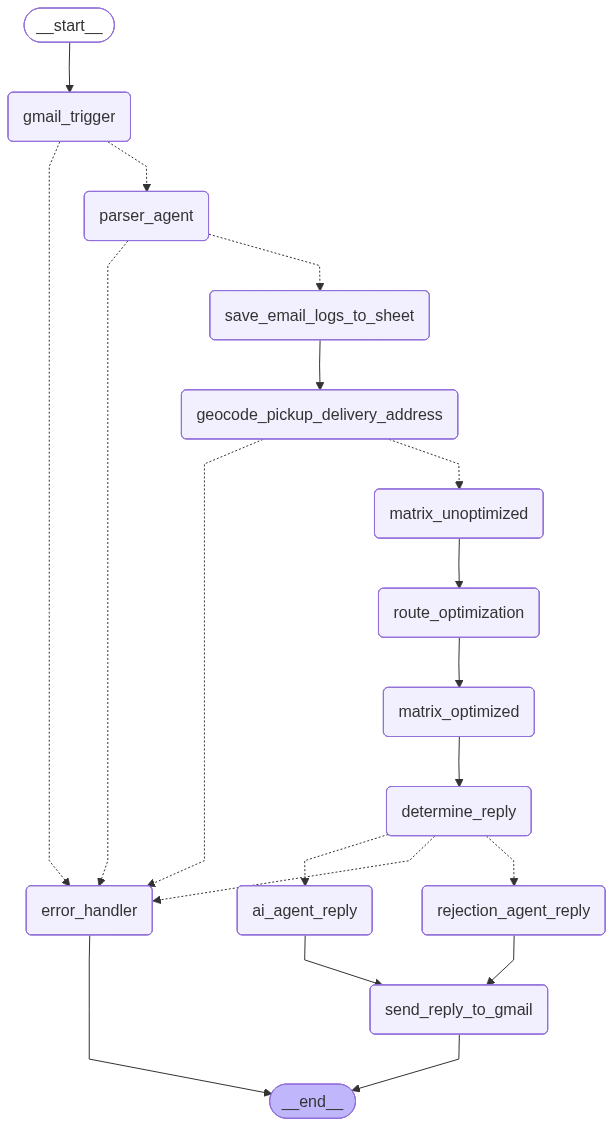

In [35]:
def build_graph():
    builder = StateGraph(LogisticsState)

    # ── Register nodes ───────────────────────────────────────────────
    builder.add_node('gmail_trigger',                   gmail_trigger)
    builder.add_node('parser_agent',                    parser_agent)
    builder.add_node('save_email_logs_to_sheet',        save_email_logs_to_sheet)
    builder.add_node('geocode_pickup_delivery_address', geocode_pickup_delivery_address)
    builder.add_node('matrix_unoptimized',              matrix_unoptimized)    # parallel
    builder.add_node('route_optimization',              route_optimization)    # parallel
    builder.add_node('matrix_optimized',                matrix_optimized)      # after opt
    builder.add_node('determine_reply',                 determine_reply)       # fan-in
    builder.add_node('ai_agent_reply',                  ai_agent_reply)
    builder.add_node('rejection_agent_reply',           rejection_agent_reply)
    builder.add_node('send_reply_to_gmail',             send_reply_to_gmail)
    builder.add_node('error_handler',                   error_handler)

    # ── Sequential preamble ──────────────────────────────────────────
    builder.add_edge(START, 'gmail_trigger')

    builder.add_conditional_edges('gmail_trigger', route_after_trigger,
        {'parser_agent': 'parser_agent', 'error_handler': 'error_handler'})

    builder.add_conditional_edges('parser_agent', route_after_parse,
        {'save_email_logs_to_sheet': 'save_email_logs_to_sheet',
         'error_handler': 'error_handler'})

    builder.add_edge('save_email_logs_to_sheet', 'geocode_pickup_delivery_address')

    # geocode routes to error_handler on failure, else goes to matrix_unoptimized
    builder.add_conditional_edges('geocode_pickup_delivery_address', route_after_geocode,
        {'matrix_unoptimized': 'matrix_unoptimized',
         'error_handler': 'error_handler'})

    # ── Parallel branch: matrix_unoptimized and route_optimization run after geocode ───────
    # matrix_unoptimized is the entry point from geocode, route_optimization runs in parallel
    builder.add_edge('matrix_unoptimized', 'route_optimization')
    builder.add_edge('route_optimization', 'matrix_optimized')

    # ── Fan-in: matrix_optimized is the last node in the chain ─
    builder.add_edge('matrix_optimized', 'determine_reply')

    # ── Route to reply ───────────────────────────────────────────────
    builder.add_conditional_edges('determine_reply', route_after_determine,
        {'ai_agent_reply':       'ai_agent_reply',
         'rejection_agent_reply': 'rejection_agent_reply',
         'error_handler':        'error_handler'})

    builder.add_edge('ai_agent_reply',        'send_reply_to_gmail')
    builder.add_edge('rejection_agent_reply', 'send_reply_to_gmail')
    builder.add_edge('send_reply_to_gmail',   END)
    builder.add_edge('error_handler',         END)

    app = builder.compile(checkpointer=MemorySaver())
    log.info(
        'LangGraph compiled: 12 nodes | '
        'Parallel: matrix_unoptimized ∥ [route_optimization → matrix_optimized] | '
        'Fan-in: determine_reply'
    )
    return app


app = build_graph()
app


## Main Polling Loop

In [36]:
from tools.gmail_tools import poll_gmail_inbox

POLL_INTERVAL = int(os.getenv('GMAIL_POLL_INTERVAL', '60'))
GMAIL_QUERY   = os.getenv('GMAIL_QUERY', 'is:unread subject:Pickup Schedule')


def process_email(app, raw_email: str, thread_id: str, sender_email: str) -> dict:
    config = {'configurable': {'thread_id': thread_id}}
    state: LogisticsState = {
        'raw_email_content':     raw_email,
        'sender_email':          sender_email,
        'thread_id':             thread_id,
        'collection_request_id': '',
        'parsed_stops':          [],
        'geocoded_stops':        [],
        'sender_company':        '',
        'reply_html':            '',
        'email_log_saved':       False,
        'error':                 None,
        'rejected_stops':        [],
        'depot_latitude':        None,
        'depot_longitude':       None,
        'vehicle_count':         0,
        'opt_summary':           None,
        'opt_routes':            [],
        'ordered_stops':         [],
        'unoptimized_matrix':    None,
        'optimized_matrix':      None,
    }
    log.info('Processing email from %s (thread: %s)', sender_email, thread_id)
    result = app.invoke(state, config=config)

    if result.get('error'):
        log.error('Workflow failed [%s] for thread %s', result['error'], thread_id)
    else:
        log.info('Done. Reply sent to %s (%s)', sender_email, result.get('collection_request_id', ''))
    return result


def main():
    log.info('Gmail polling every %ds. Query: %r', POLL_INTERVAL, GMAIL_QUERY)
    processed_ids: set = set()

    while True:
        try:
            emails = poll_gmail_inbox.invoke({'query': GMAIL_QUERY})
            new_emails = [e for e in emails if e['message_id'] not in processed_ids]
            if new_emails:
                log.info('Found %d new email(s).', len(new_emails))
            for email in new_emails:
                processed_ids.add(email['message_id'])
                process_email(app, email['body'], email['thread_id'], email['sender_email'])
        except Exception as exc:
            log.exception('Polling error: %s', exc)
        time.sleep(POLL_INTERVAL)


main()

2026-04-15 00:24:02,254 [INFO] Gmail polling every 60s. Query: 'is:unread subject:Pickup Schedule'
2026-04-15 00:24:03,643 [INFO] Found 1 new email(s).
2026-04-15 00:24:03,645 [INFO] Processing email from Anuj Mumbaikar <anuj.mumbaikar05@gmail.com> (thread: 19d8d568ba2e550e)
2026-04-15 00:24:05,268 [INFO] New request: REQ-20260414-403c1d (thread: 19d8d568ba2e550e)
2026-04-15 00:24:12,494 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-15 00:24:12,521 [INFO] Parsed 6 stops (sender: DM-Reckers pvt LTD)
2026-04-15 00:24:18,130 [INFO] Logs saved: 6 stops for REQ-20260414-403c1d
2026-04-15 00:24:19,872 [INFO] Geocoded pickup stop 1: (19.13158, 72.89142)
2026-04-15 00:24:21,410 [INFO] Geocoded delivery stop 1: (19.23971, 73.03407)
2026-04-15 00:24:23,109 [INFO] Geocoded pickup stop 2: (18.51594, 73.84244)
2026-04-15 00:24:24,735 [INFO] Geocoded delivery stop 2: (19.23971, 73.03407)
2026-04-15 00:24:26,452 [INFO] Geocoded pickup stop 3: (20.01235

KeyboardInterrupt: 